# Audio Keyword Recognition — Speech Commands v0.01

**Foundations of Deep Learning — Academic Year 2025/2026**
Group: Abdul Sami · Samuele Urosevic · Thilina Lakshan

12-class spoken-command classification. Each 1-second audio clip is converted into
a log-mel spectrogram and classified with a convolutional neural network trained
from scratch. A MobileNetV2 transfer-learning model is included as a baseline for
comparison.

**Pipeline:** `raw .wav` → log-mel spectrogram `(64, 32, 1)` → CNN → 12 classes.

## 1. Configuration

All paths derive from a single `BASE` directory. Random seeds are fixed for
reproducibility. The dataset is expected to be already extracted under
`DATA_DIR`.

In [3]:
import os
import random
import numpy as np
import tensorflow as tf

# Project root — edit to match your machine
BASE = "/Users/samuuro/Desktop/DATA SCIENCE/FOUNDATIONS OF DEEP LEARNING/PROJECT"
DATA_DIR  = os.path.join(BASE, "speech_commands_v0.01")
SAVE_PATH = os.path.join(BASE, "best_model.keras")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Class definition

Ten target commands are kept as individual classes; `_background_noise_` is mapped
to `silence`; all remaining words are grouped into `unknown`, for 12 classes
total. Labels are encoded as integers.

In [2]:
TARGET_CLASSES = ['yes', 'no', 'up', 'down', 'left',
                  'right', 'on', 'off', 'stop', 'go']

ALL_CLASSES = TARGET_CLASSES + ['silence', 'unknown']
LABEL2IDX   = {c: i for i, c in enumerate(ALL_CLASSES)}
IDX2LABEL   = {i: c for c, i in LABEL2IDX.items()}

print("Classes:", len(ALL_CLASSES))

Classes: 12


## 3. Feature extraction

Each clip is loaded at 16 kHz, padded/truncated to exactly 1 second, transformed
into a 64-band mel spectrogram, converted to decibels, normalised to [0, 1], and
given a channel axis, yielding a `(64, 32, 1)` tensor.

In [4]:
import librosa

def extract_mel(file_path, sr=16000, n_mels=64, hop_length=512):
    # Returns a normalised log-mel spectrogram of shape (64, 32, 1), or None on error.
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=1.0)
        if len(y) < sr:
            y = np.pad(y, (0, sr - len(y)))
        else:
            y = y[:sr]
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=512, hop_length=hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel[..., np.newaxis]
    except Exception:
        return None

## 4. Dataset construction

Iterate over every class folder, extract spectrograms, and assemble the feature
array `X` and label array `y`.

In [5]:
from tqdm.notebook import tqdm

X, y = [], []
skipped = 0

for folder in tqdm(sorted(os.listdir(DATA_DIR)), desc="Loading"):
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue

    if folder == '_background_noise_':
        label = 'silence'
    elif folder in TARGET_CLASSES:
        label = folder
    else:
        label = 'unknown'
    idx = LABEL2IDX[label]

    for fname in os.listdir(folder_path):
        if not fname.endswith('.wav'):
            continue
        mel = extract_mel(os.path.join(folder_path, fname))
        if mel is not None:
            X.append(mel)
            y.append(idx)
        else:
            skipped += 1

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print("X:", X.shape, "| y:", y.shape, "| skipped:", skipped)

Loading:   0%|          | 0/36 [00:00<?, ?it/s]

X: (64727, 64, 32, 1) | y: (64727,) | skipped: 0


## 5. Train / validation / test split

Stratified 70 / 15 / 15 split to preserve class proportions across all subsets.

In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=SEED
)
print("Train:", X_train.shape[0], "| Val:", X_val.shape[0], "| Test:", X_test.shape[0])

Train: 45334 | Val: 9683 | Test: 9710


## 6. Data analysis

Class distribution and example spectrograms. The dataset is strongly imbalanced:
`unknown` dominates and `silence` is severely under-represented.

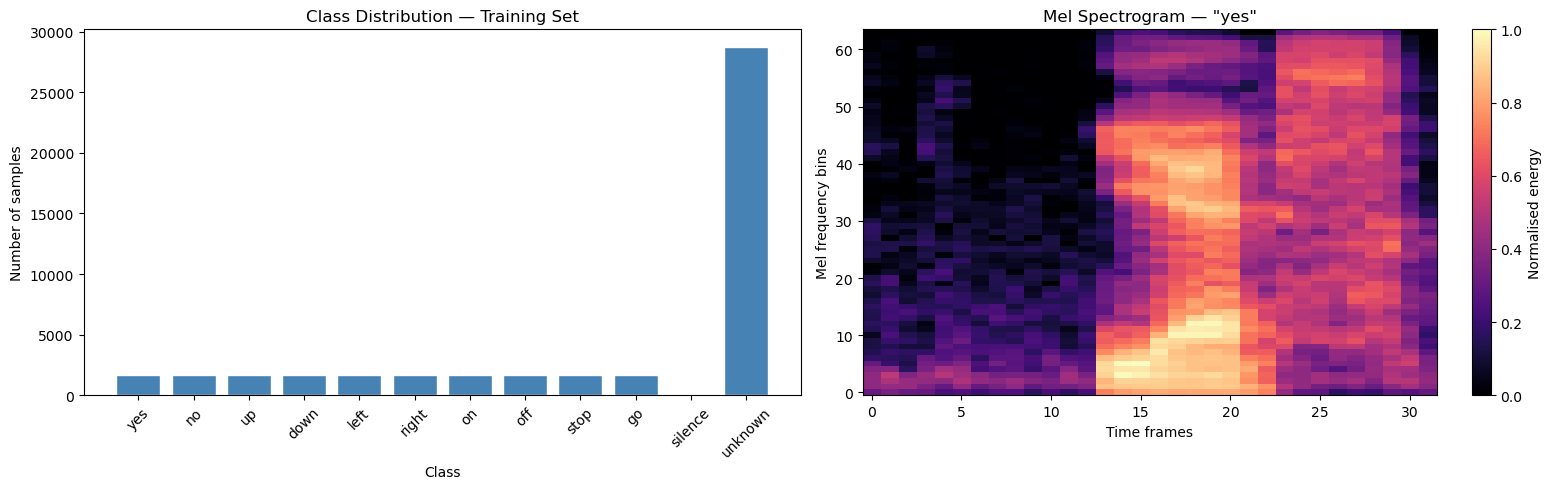

     yes: 1664
      no: 1664
      up: 1664
    down: 1652
    left: 1648
   right: 1658
      on: 1658
     off: 1650
    stop: 1667
      go: 1661
 silence: 4
 unknown: 28744


In [7]:
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

train_counts = Counter(y_train)
labels_plot = [IDX2LABEL[i] for i in sorted(train_counts)]
counts_plot = [train_counts[i] for i in sorted(train_counts)]

axes[0].bar(labels_plot, counts_plot, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — Training Set')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Number of samples')
axes[0].tick_params(axis='x', rotation=45)

sample_idx = np.where(y_train == LABEL2IDX['yes'])[0][0]
im = axes[1].imshow(X_train[sample_idx, :, :, 0], aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Mel Spectrogram — "yes"')
axes[1].set_xlabel('Time frames'); axes[1].set_ylabel('Mel frequency bins')
plt.colorbar(im, ax=axes[1], label='Normalised energy')

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

for i in sorted(train_counts):
    print(f"{IDX2LABEL[i]:>8}: {train_counts[i]}")

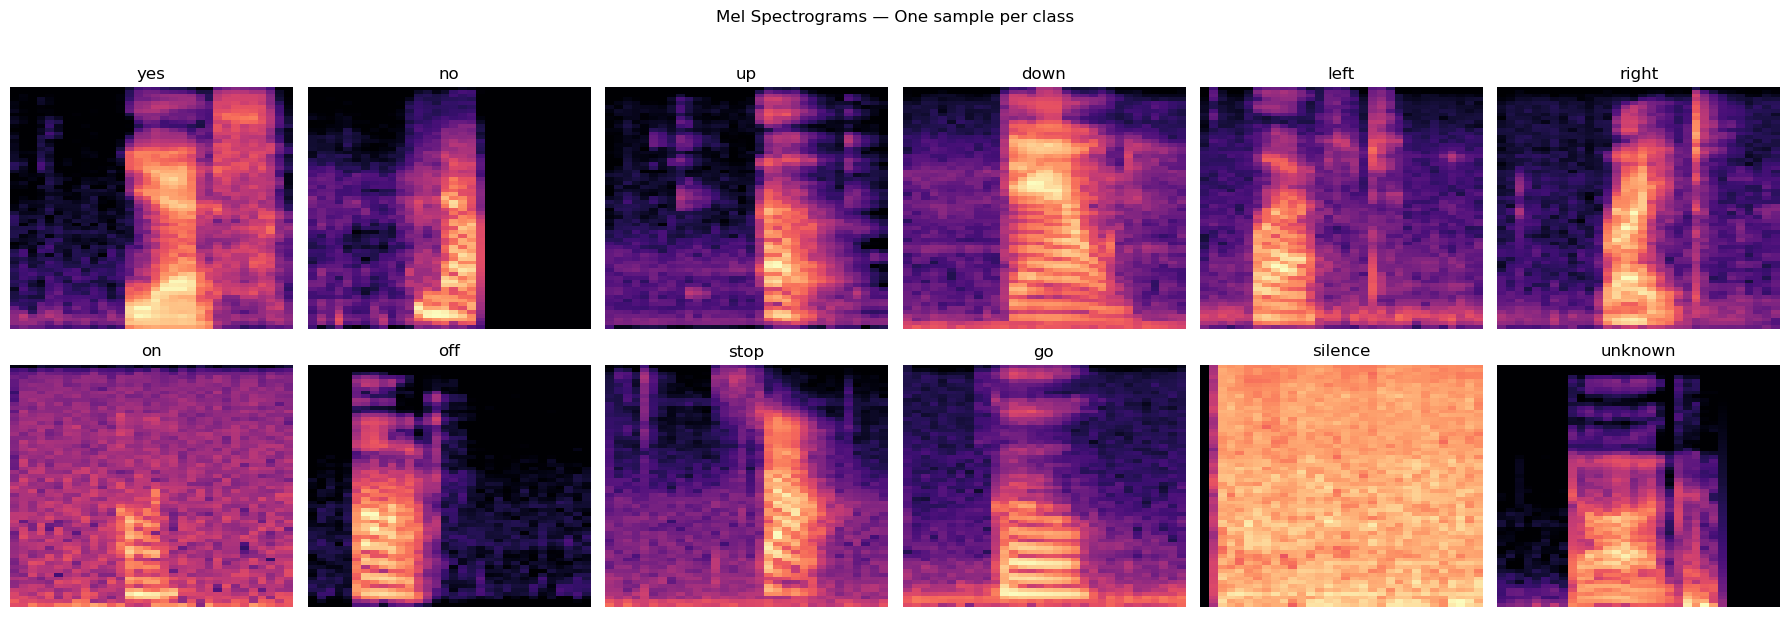

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()
for i, cls in enumerate(ALL_CLASSES):
    idx_list = np.where(y_train == i)[0]
    if len(idx_list) == 0:
        axes[i].axis('off'); continue
    axes[i].imshow(X_train[idx_list[0], :, :, 0], aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(cls); axes[i].axis('off')
plt.suptitle('Mel Spectrograms — One sample per class', y=1.02)
plt.tight_layout()
plt.savefig('spectrograms_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. CNN model

Three convolutional blocks (32 → 64 → 128 filters) with batch normalisation, max
pooling and dropout, followed by global average pooling and a dense classifier
head with softmax output.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_shape=(64, 32, 1), num_classes=12):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,676 (506.55 KB)

 Trainable params: 129,228 (504.80 KB)

 Non-trainable params: 448 (1.75 KB)

## 8. Training

Adam optimiser with early stopping, learning-rate reduction on plateau, and best-
model checkpointing.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(SAVE_PATH, monitor='val_accuracy',
                                    save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=64,
    callbacks=callbacks, verbose=1
)

Epoch 1/15
709/709 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6218 - loss: 1.4879
Epoch 1: val_accuracy improved from None to 0.70588, saving model to /Users/samuuro/Desktop/DATA SCIENCE/FOUNDATIONS OF DEEP LEARNING/PROJECT/best_model.keras

Epoch 1: finished saving model to /Users/samuuro/Desktop/DATA SCIENCE/FOUNDATIONS OF DEEP LEARNING/PROJECT/best_model.keras
709/709 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.6618 - loss: 1.2170 - val_accuracy: 0.7059 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 2/15
708/709 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7685 - loss: 0.7084
Epoch 2: val_accuracy improved from 0.70588 to 0.87008, saving model to /Users/samuuro/Desktop/DATA SCIENCE/FOUNDATIONS OF DEEP LEARNING/PROJECT/best_model.keras

Epoch 2: finished saving model to /Users/samuuro/Desktop/DATA SCIENCE/FOUNDATIONS OF DEEP LEARNING/PROJECT/best_model.keras
709/709 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7935 - loss: 0.6298 - val_accuracy: 0.8701 - val_loss: 

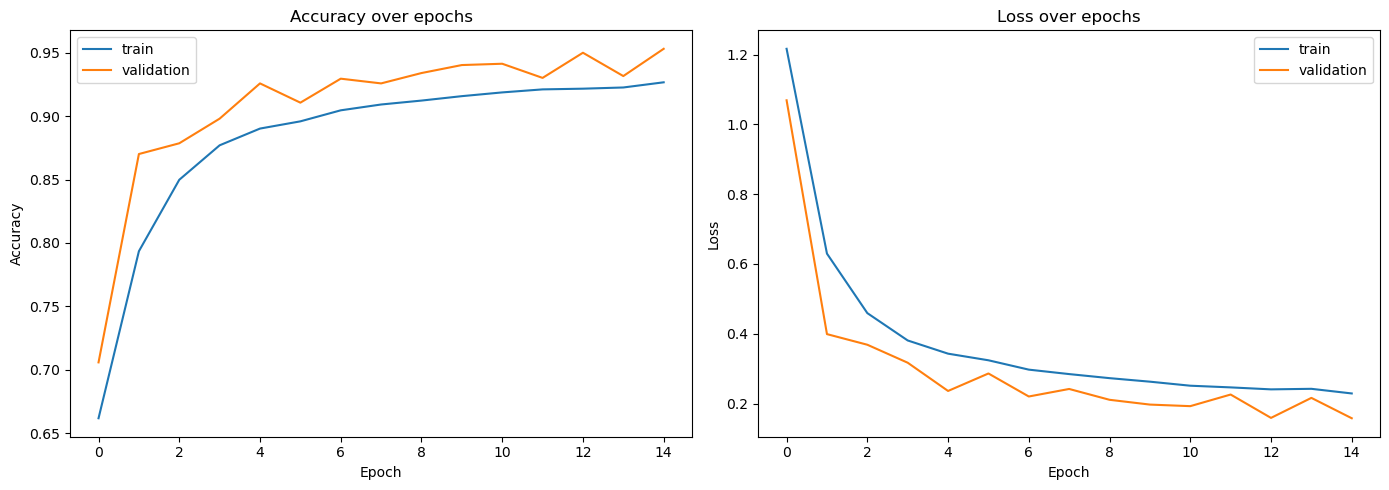

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation

Test-set accuracy, per-class precision/recall/F1, and confusion matrix. Because of
the class imbalance, the macro-average F1 is the most representative summary
metric.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=ALL_CLASSES, zero_division=0))

Test Loss     : 0.1607
Test Accuracy : 0.9510 (95.10%)
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

         yes       0.97      0.96      0.97       357
          no       0.87      0.94      0.90       356
          up       0.80      0.96      0.88       356
        down       0.94      0.88      0.91       354
        left       0.98      0.90      0.94       353
       right       0.95      0.94      0.94       355
          on       0.95      0.93      0.94       355
         off       0.97      0.87      0.92       354
        stop       1.00      0.89      0.94       357
          go       0.84      0.88      0.86       356
     silence       0.00      0.00      0.00         1
     unknown       0.97      0.97      0.97      6156

    accuracy                           0.95      9710
   macro avg       0.85      0.84      0.85      9710
weighted avg       0.95      0.95      0.95      9710



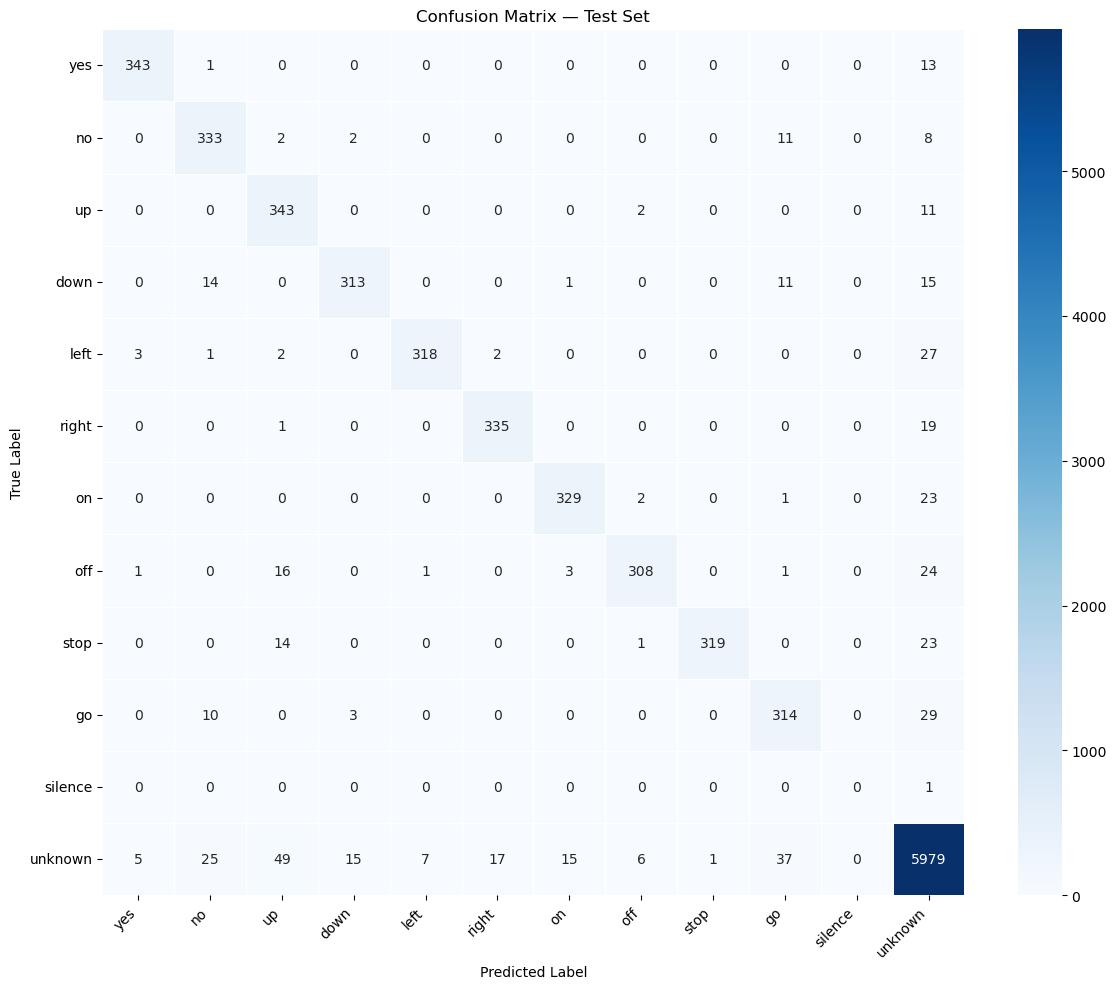

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Baseline experiment — transfer learning (MobileNetV2)

MobileNetV2 pretrained on ImageNet is used as a frozen feature extractor, with a
new classifier head trained on top. Spectrograms are converted to 3-channel 96×96
inputs. This baseline is compared against the from-scratch CNN.

In [16]:
def mel_to_rgb(mel_batch):
    rgb = np.repeat(mel_batch, 3, axis=-1)
    rgb = tf.image.resize(rgb, [96, 96]).numpy()
    return rgb.astype(np.float32)

X_train_rgb = mel_to_rgb(X_train)
X_val_rgb   = mel_to_rgb(X_val)
X_test_rgb  = mel_to_rgb(X_test)

base = keras.applications.MobileNetV2(input_shape=(96, 96, 3),
                                      include_top=False, weights='imagenet')
base.trainable = False

inp = keras.Input(shape=(96, 96, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inp)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
out = layers.Dense(12, activation='softmax')(x)

tl_model = keras.Model(inp, out)
tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

tl_model.fit(X_train_rgb, y_train, validation_data=(X_val_rgb, y_val),
             epochs=20, batch_size=64, verbose=1)

tl_loss, tl_acc = tl_model.evaluate(X_test_rgb, y_test, verbose=0)
print(f"\nMobileNetV2 Test Accuracy : {tl_acc:.4f} ({tl_acc*100:.2f}%)")
print(f"From-scratch CNN Accuracy : {acc:.4f} ({acc*100:.2f}%)")

from sklearn.metrics import classification_report
y_pred_tl = np.argmax(tl_model.predict(X_test_rgb), axis=1)
print("\nMobileNetV2 Classification Report:")
print(classification_report(y_test, y_pred_tl, target_names=ALL_CLASSES, zero_division=0))

Epoch 1/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.6340 - loss: 1.5166 - val_accuracy: 0.6340 - val_loss: 1.5125
Epoch 2/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6340 - loss: 1.5064 - val_accuracy: 0.6340 - val_loss: 1.5160
Epoch 3/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 51s 71ms/step - accuracy: 0.6340 - loss: 1.5044 - val_accuracy: 0.6340 - val_loss: 1.5147
Epoch 4/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.6340 - loss: 1.5031 - val_accuracy: 0.6340 - val_loss: 1.5135
Epoch 5/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6340 - loss: 1.5021 - val_accuracy: 0.6340 - val_loss: 1.5129
Epoch 6/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.6340 - loss: 1.5010 - val_accuracy: 0.6340 - val_loss: 1.5112
Epoch 7/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.6340 - loss: 1.5001 - val_accuracy: 0.6340 - val_loss: 1.5105
Epoch 8/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.6340 - loss: 1.4992 - 

## 11. Save models

In [15]:
model.save(os.path.join(BASE, 'best_model.keras'))
tl_model.save(os.path.join(BASE, 'mobilenet_baseline.keras'))
print("Models saved.")

Models saved.
